# **BANK COSTUMER CHURN**

### Libraries import

In [6]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

sns.set(style="whitegrid", palette="muted", font_scale=1.1)

# Bank Customer Churn Analysis

The objective of this project is to analyze the factors that influence customer churn in a bank and to propose data-driven retention strategies.

In [ ]:
# Load data
df = pd.read_csv("../Data/Bank_Customer_Churn_Prediction.csv")

# Drop ID column
df = df.drop('customer_id', axis=1)

df.head()

,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


# Predictive analysis

## Preparing data

### Encode categorical variables

In [8]:
# Columns to encode
categorical_cols = ['country','gender','credit_card','active_member']

from sklearn.preprocessing import LabelEncoder
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

### Scale numerical features

In [9]:
numerical_cols = ['credit_score','age','tenure','balance','products_number','estimated_salary']
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

### Split features and target

In [10]:
X = df.drop('churn', axis=1)
y = df['churn']

### Train-test split

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

## Train models

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    roc = roc_auc_score(y_test, y_pred)
    print(f"{name} ROC-AUC: {roc:.3f}")

Logistic Regression ROC-AUC: 0.558
Random Forest ROC-AUC: 0.709


## Confusion matrix and classification report

              precision    recall  f1-score   support

           0       0.87      0.96      0.92      1593
           1       0.76      0.45      0.57       407

    accuracy                           0.86      2000
   macro avg       0.82      0.71      0.74      2000
weighted avg       0.85      0.86      0.85      2000



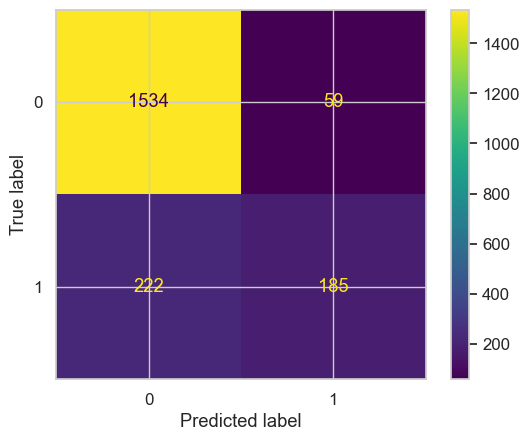

In [14]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

best_model = RandomForestClassifier(n_estimators=200, random_state=42)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

## Feature importance

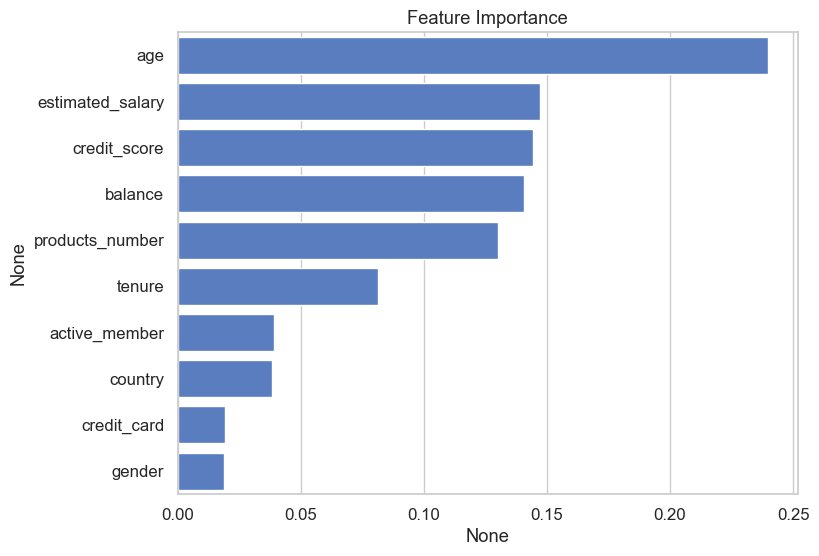

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8,6))
sns.barplot(x=importances, y=importances.index)
plt.title("Feature Importance")
plt.show()

## Permutation feature importance

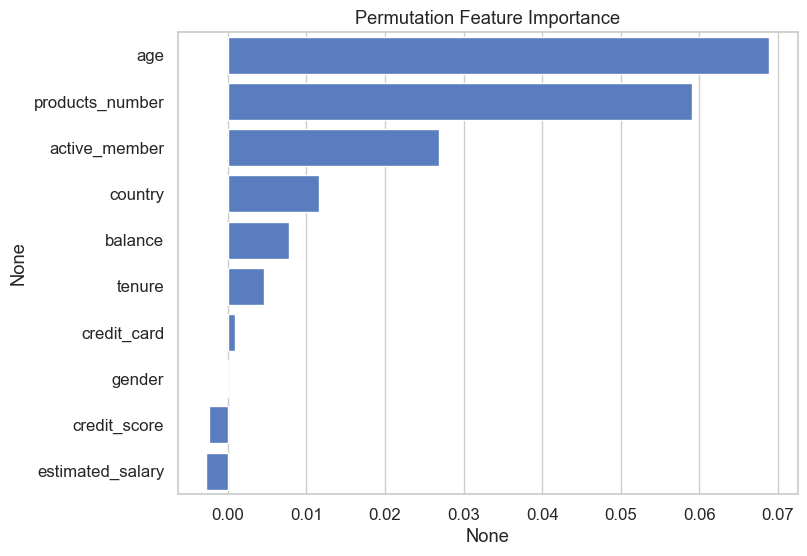

In [16]:
from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(best_model, X_test, y_test, n_repeats=10, random_state=42)
perm_importances = pd.Series(perm_importance.importances_mean, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x=perm_importances, y=perm_importances.index)
plt.title("Permutation Feature Importance")
plt.show()

## Cross-validation (Robustness check)

In [17]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Stratified K-Fold ensures churn ratio is maintained in each fold
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(best_model, X, y, cv=kf, scoring='roc_auc')
print("Cross-validated ROC-AUC scores:", cv_scores)
print("Mean ROC-AUC:", cv_scores.mean())

Cross-validated ROC-AUC scores: [0.85183962 0.84561287 0.84773757 0.85349448 0.86276646]
Mean ROC-AUC: 0.8522902004625099


# Predict churn for each customer

In [18]:
# Predict churn for the whole dataset
df['predicted_churn'] = best_model.predict(X)

# Compare prediction vs actual
df['correct_prediction'] = df['predicted_churn'] == df['churn']

# Accuracy
overall_accuracy = df['correct_prediction'].mean()
print(f"Overall accuracy: {overall_accuracy:.2f}")

# Display first 10 predictions
df[['churn', 'predicted_churn', 'correct_prediction']].head(10)

Overall accuracy: 0.97


,churn,predicted_churn,correct_prediction
0,1,1,True
1,0,0,True
2,1,1,True
3,0,0,True
4,0,0,True
5,1,1,True
6,0,0,True
7,1,1,True
8,0,0,True
9,0,0,True


# Evaluation

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.99      0.98      7963
           1       0.97      0.89      0.93      2037

    accuracy                           0.97     10000
   macro avg       0.97      0.94      0.96     10000
weighted avg       0.97      0.97      0.97     10000



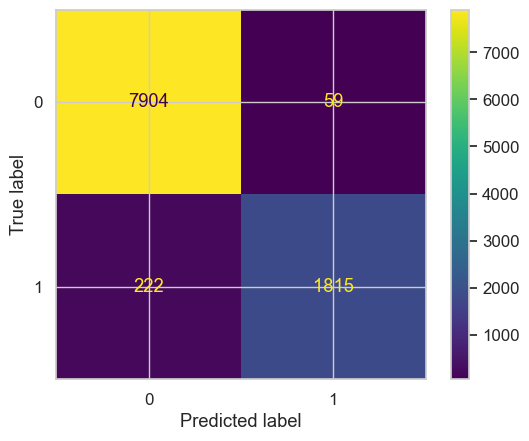

In [19]:
from sklearn.metrics import classification_report, confusion_matrix

print("Classification Report:\n")
print(classification_report(df['churn'], df['predicted_churn']))

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(df['churn'], df['predicted_churn'])
plt.show()